# Welcome to Modal notebooks!

Write Python code and collaborate in real time. Your code runs in Modal's
**serverless cloud**, and anyone in the same workspace can join.

This notebook comes with some common Python libraries installed. Run
cells with `Shift+Enter`.

In [1]:
!nvidia-smi

Sun Jun  7 17:12:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:00:09.0 Off |                    0 |
| N/A   37C    P0             74W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [8]:
import os
try:
    from dotenv import load_dotenv; load_dotenv()   # picks up HF_TOKEN / WANDB from a local .env
except Exception:
    pass

# --- model ---
MODEL_ID   = "openbmb/MiniCPM-V-4.6"     # the trainable safetensors base (NOT the GGUF)
MODEL_TYPE = "minicpmv4_6"               # ms-swift model_type for MiniCPM-V 4.6 (no hyphens!)

# --- auth (Modal: use Secrets; local: from .env; or paste here) ---
HF_TOKEN = os.environ.get("HF_TOKEN", "")
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN

# Make ms-swift fetch the base model from Hugging Face (fast CDN, uses HF_TOKEN) instead of
# its default ModelScope Hub, which is slow (~700 kB/s) from US/Modal datacenters.
os.environ["USE_HF"] = "1"

# --- dataset (already uploaded) ---
HF_DATASET_REPO = os.environ.get("RG_DATASET_REPO", "ASHu2/rune_goblin_visual_dataset")
DATASET_DIR     = os.environ.get("RG_DATASET_DIR", "rune_goblin_visual_dataset")

# --- ONE Hub repo for everything: merged safetensors (root), LoRA (lora/), GGUF (gguf/) ---
MODEL_REPO = "ASHu2/goblinV1"
OUTPUT_DIR = "outputs/rune-goblin-vision-lora"

# --- experiment tracking (Weights & Biases) ---
WANDB_API_KEY = os.environ.get("WANDB") or os.environ.get("WANDB_API_KEY", "")
WANDB_PROJECT = "goblin"
if WANDB_API_KEY:
    os.environ["WANDB_API_KEY"] = WANDB_API_KEY
    os.environ["WANDB_PROJECT"] = WANDB_PROJECT
REPORT_TO = "wandb" if WANDB_API_KEY else "none"

# --- hyperparameters (sensible defaults for the 5k set) ---
EPOCHS      = 3
LORA_RANK   = 16
LORA_ALPHA  = 32
LR          = 1e-4
BATCH       = 16          # per-device; lower to 1-2 on a 24GB card
GRAD_ACCUM  = 1          # effective batch = BATCH * GRAD_ACCUM
MAX_LEN     = 2048
FREEZE_VIT  = True       # train LLM+resampler only. False to also adapt the vision tower.

print("model :", MODEL_ID)
print("data  :", HF_DATASET_REPO)
print("output:", MODEL_REPO)
print("token :", bool(HF_TOKEN), "| wandb:", "on" if WANDB_API_KEY else "off")

model : openbmb/MiniCPM-V-4.6
data  : ASHu2/rune_goblin_visual_dataset
output: ASHu2/goblinV1
token : True | wandb: on


In [3]:
%uv pip install -q -U "ms-swift>=3.0" "transformers>=4.49" "accelerate>=0.34" \
    peft timm pillow sentencepiece "trl<1.0" qwen-vl-utils wandb
# Optional (faster attention, needs a compile): %pip install -q flash-attn --no-build-isolation
import subprocess
print(subprocess.run(["swift", "--help"], capture_output=True, text=True).stdout[:200] or "swift installed")

Note: you may need to restart the kernel to use updated packages.
swift installed


In [4]:
import zipfile
from pathlib import Path
from huggingface_hub import snapshot_download

if HF_DATASET_REPO:
    # pull jsonl/metadata + the single images.zip; skip the 5000 loose images/ files
    DATASET_DIR = snapshot_download(
        repo_id=HF_DATASET_REPO, repo_type="dataset",
        local_dir="rg_visual_data", token=HF_TOKEN or None,
        allow_patterns=["*.jsonl", "*.json", "*.csv", "*.md", "images.zip"],
    )

root = Path(DATASET_DIR).resolve()
zip_path = root / "images.zip"
if zip_path.exists() and not (root / "images").exists():
    print("unzipping images.zip ...")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(root)

print("DATASET_DIR =", root)
need = ["train_messages.jsonl", "validation_messages.jsonl", "images"]
missing = [n for n in need if not (root / n).exists()]
assert not missing, f"missing in DATASET_DIR: {missing}. Set HF_DATASET_REPO or mount the folder."
print("images on disk:", len(list((root / "images").glob("*.jpg"))))

Fetching ... files: 0it [00:00, ?it/s]

DATASET_DIR = /root/rg_visual_data
images on disk: 4999


In [5]:
import json, os

def to_swift(src, dst):
    kept, skipped = 0, 0
    with open(src) as f, open(dst, "w") as o:
        for line in f:
            r = json.loads(line)
            img = str((root / r["image"]).resolve())
            if not os.path.exists(img):   # source dataset references one missing image
                skipped += 1
                continue
            print(json.dumps({"messages": r["messages"], "images": [img]}, ensure_ascii=False), file=o)
            kept += 1
    return kept, skipped

TRAIN = "rg_swift_train.jsonl"
VAL   = "rg_swift_val.jsonl"
for split, dst in [("train_messages.jsonl", TRAIN), ("validation_messages.jsonl", VAL)]:
    kept, skipped = to_swift(root / split, dst)
    print(f"{split}: kept {kept}" + (f", skipped {skipped} (missing image)" if skipped else ""))

train_messages.jsonl: kept 4499, skipped 1 (missing image)
validation_messages.jsonl: kept 500


USER:
 <image>
STATE: player_hp=4 enemy=Wet Librarian enemy_hp=5 weakness=bell, leaf resistance=flame room=The Wet Library room_mood=too quiet inventory=[mirror shard, sad onion]
Look at the drawn RuneLang spell on the canvas and return visual_reading plus spell JSON only. 

TARGET JSON:
 {
  "visual_reading": {
    "detected_runes": [
      "leaf",
      "bone"
    ],
    "ambiguous_runes": [],
    "drawing_style": "uneven mouse-drawn strokes",
    "layout": "loose circular cluster",
    "confidence": 0.94,
    "notes": [
      "recognized_combo_rule"
    ]
  },
  "spell": {
    "spell_name": "Improper Leaf Undertaker",
    "spell_type": "decay_healing",
    "flavor": "The symbols crawl off the canvas, argue for a second, then become magic.",
    "effect": "Deals 2 damage to Wet Librarian. It bites into the enemy weakness (bell, leaf).",
    "side_effect": "The healing smells like compost; decay risk may matter next turn.",
    "enemy_hp_delta": -2,
    "player_hp_delta": -1


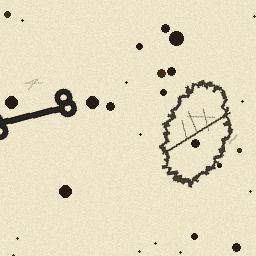

In [6]:
import json
from PIL import Image
from IPython.display import display

rec = json.loads(open("rg_swift_train.jsonl").readline())
user = next(m["content"] for m in rec["messages"] if m["role"] == "user")
asst = next(m["content"] for m in rec["messages"] if m["role"] == "assistant")
print("USER:\n", user, "\n")
print("TARGET JSON:\n", json.dumps(json.loads(asst), indent=2)[:700])
display(Image.open(rec["images"][0]).resize((256, 256)))

In [9]:
import os, subprocess
from datetime import datetime

# W&B in `swift sft` is configured via ENV + --report_to (NOT --wandb_project/--wandb_exp_name,
# which are Megatron-SWIFT flags). W&B auto-reads WANDB_PROJECT / WANDB_NAME from the env.
WANDB_EXP_NAME = "rune-goblin-v46-lora-" + datetime.now().strftime("%Y%m%d-%H%M%S")
if REPORT_TO == "wandb":
    os.environ["WANDB_PROJECT"] = WANDB_PROJECT
    os.environ["WANDB_NAME"] = WANDB_EXP_NAME

args = [
    "swift", "sft",
    "--model", MODEL_ID,
    "--model_type", MODEL_TYPE,
    "--dataset", TRAIN,
    "--val_dataset", VAL,
    # train_type defaults to "lora" in ms-swift; --lora_rank/--lora_alpha configure it.
    # (ms-swift 4.x dropped the --train_type flag name.)
    "--lora_rank", str(LORA_RANK), "--lora_alpha", str(LORA_ALPHA),
    "--freeze_vit", str(FREEZE_VIT).lower(),
    "--torch_dtype", "bfloat16", "--attn_impl", "sdpa",
    "--num_train_epochs", str(EPOCHS),
    "--per_device_train_batch_size", str(BATCH),
    "--gradient_accumulation_steps", str(GRAD_ACCUM),
    "--learning_rate", str(LR),
    "--max_length", str(MAX_LEN),
    "--gradient_checkpointing", "true",
    "--warmup_ratio", "0.03",
    "--eval_steps", "200", "--save_steps", "200", "--logging_steps", "10",
    "--save_total_limit", "2",
    "--dataset_num_proc", "8",
    "--output_dir", OUTPUT_DIR,
    "--report_to", REPORT_TO,
    "--dataloader_num_workers", "8",
    
]

print(" ".join(args), "\n")
ret = subprocess.run(args).returncode
print("\nswift sft exit code:", ret)

swift sft --model openbmb/MiniCPM-V-4.6 --model_type minicpmv4_6 --dataset rg_swift_train.jsonl --val_dataset rg_swift_val.jsonl --lora_rank 16 --lora_alpha 32 --freeze_vit true --torch_dtype bfloat16 --attn_impl sdpa --num_train_epochs 3 --per_device_train_batch_size 16 --gradient_accumulation_steps 1 --learning_rate 0.0001 --max_length 2048 --gradient_checkpointing true --warmup_ratio 0.03 --eval_steps 200 --save_steps 200 --logging_steps 10 --save_total_limit 2 --dataset_num_proc 8 --output_dir outputs/rune-goblin-vision-lora --report_to wandb --dataloader_num_workers 8 

run sh: `/usr/local/bin/python /usr/local/lib/python3.12/site-packages/swift/cli/sft.py --model openbmb/MiniCPM-V-4.6 --model_type minicpmv4_6 --dataset rg_swift_train.jsonl --val_dataset rg_swift_val.jsonl --lora_rank 16 --lora_alpha 32 --freeze_vit true --torch_dtype bfloat16 --attn_impl sdpa --num_train_epochs 3 --per_device_train_batch_size 16 --gradient_accumulation_steps 1 --learning_rate 0.0001 --max_length 

[INFO:swift] Successfully registered `/usr/local/lib/python3.12/site-packages/swift/dataset/data/dataset_info.json`.
[INFO:swift] rank: -1, local_rank: -1, world_size: 1, local_world_size: 1
[INFO:swift] Downloading the model from HuggingFace Hub, model_id: openbmb/MiniCPM-V-4.6
Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 5898.12it/s]
[INFO:swift] Loading the model using model_dir: /root/.cache/huggingface/hub/models--openbmb--MiniCPM-V-4.6/snapshots/d7f5ed8d15462c508d4f9d9ce5a0cf1fe8d87bcc
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[INFO:swift] Because len(args.val_dataset) > 0, setting split_dataset_ratio: 0.0
[INFO:swift] Setting args.lazy_tokenize: True
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[INFO:swift] output_dir: /root/outputs/rune-goblin-vision-lora/v2-20260607-171815
[INFO:swift] args: SftArguments(
acc_strategy=token,
accelerator_config={'dispatch_batches': False},
adalora_beta1=0.85,
a

{'loss': '4.957', 'grad_norm': '26.48', 'learning_rate': '3.85e-06', 'token_acc': '0.3279', 'epoch': '0.003546', 'global_step/max_steps': '1/846', 'elapsed_time': '10s', 'remaining_time': '2h 18m 4s', 'memory(GiB)': '31.36', 'train_speed(s/it)': '9.804'}
{'loss': '4.304', 'grad_norm': '6.98', 'learning_rate': '3.846e-05', 'token_acc': '0.3718', 'epoch': '0.03546', 'global_step/max_steps': '10/846', 'elapsed_time': '35s', 'remaining_time': '48m 23s', 'memory(GiB)': '37.85', 'train_speed(s/it)': '3.472'}
{'loss': '2.538', 'grad_norm': '2.895', 'learning_rate': '7.692e-05', 'token_acc': '0.55', 'epoch': '0.07092', 'global_step/max_steps': '20/846', 'elapsed_time': '1m 1s', 'remaining_time': '41m 50s', 'memory(GiB)': '37.85', 'train_speed(s/it)': '3.039'}
{'loss': '1.476', 'grad_norm': '2.308', 'learning_rate': '9.999e-05', 'token_acc': '0.7191', 'epoch': '0.1064', 'global_step/max_steps': '30/846', 'elapsed_time': '1m 27s', 'remaining_time': '39m 27s', 'memory(GiB)': '37.85', 'train_speed


Val: 100%|██████████| 500/500 [03:19<00:00,  2.51it/s]
[INFO:swift] Saving model checkpoint to /root/outputs/rune-goblin-vision-lora/v2-20260607-171815/checkpoint-200
Train:  33%|███▎      | 282/846 [15:49<22:13,  2.37s/it]

{'eval_loss': '0.1572', 'eval_runtime': '201.6', 'eval_samples_per_second': '2.48', 'eval_steps_per_second': '2.48', 'eval_token_acc': '0.9455', 'epoch': '0.7092', 'global_step/max_steps': '200/846', 'elapsed_time': '12m 13s', 'remaining_time': '39m 29s', 'memory(GiB)': '37.85', 'train_speed(s/it)': '3.667'}
{'loss': '0.1601', 'grad_norm': '0.8329', 'learning_rate': '8.808e-05', 'token_acc': '0.943', 'epoch': '0.7447', 'global_step/max_steps': '210/846', 'elapsed_time': '12m 41s', 'remaining_time': '38m 25s', 'memory(GiB)': '37.85', 'train_speed(s/it)': '3.624'}
{'loss': '0.1565', 'grad_norm': '0.6964', 'learning_rate': '8.681e-05', 'token_acc': '0.9449', 'epoch': '0.7801', 'global_step/max_steps': '220/846', 'elapsed_time': '13m 8s', 'remaining_time': '37m 22s', 'memory(GiB)': '38.07', 'train_speed(s/it)': '3.581'}
{'loss': '0.1499', 'grad_norm': '0.7971', 'learning_rate': '8.549e-05', 'token_acc': '0.9468', 'epoch': '0.8156', 'global_step/max_steps': '230/846', 'elapsed_time': '13m 3

...

{'eval_loss': '0.1164', 'eval_runtime': '201.1', 'eval_samples_per_second': '2.487', 'eval_steps_per_second': '2.487', 'eval_token_acc': '0.9559', 'epoch': '2.128', 'global_step/max_steps': '600/846', 'elapsed_time': '36m 35s', 'remaining_time': '14m 60s', 'memory(GiB)': '38.07', 'train_speed(s/it)': '3.658'}
{'loss': '0.1099', 'grad_norm': '0.4465', 'learning_rate': '1.908e-05', 'token_acc': '0.9587', 'epoch': '2.163', 'global_step/max_steps': '610/846', 'elapsed_time': '37m 3s', 'remaining_time': '14m 20s', 'memory(GiB)': '38.07', 'train_speed(s/it)': '3.645'}
{'loss': '0.1122', 'grad_norm': '0.5795', 'learning_rate': '1.76e-05', 'token_acc': '0.9579', 'epoch': '2.199', 'global_step/max_steps': '620/846', 'elapsed_time': '37m 30s', 'remaining_time': '13m 40s', 'memory(GiB)': '38.07', 'train_speed(s/it)': '3.629'}
{'loss': '0.1089', 'grad_norm': '0.4398', 'learning_rate': '1.617e-05', 'token_acc': '0.9576', 'epoch': '2.234', 'global_step/max_steps': '630/846', 'elapsed_time': '37m 57s


Val: 100%|██████████| 500/500 [03:33<00:00,  2.34it/s]
[INFO:swift] Saving model checkpoint to /root/outputs/rune-goblin-vision-lora/v2-20260607-171815/checkpoint-800
Train: 100%|██████████| 846/846 [51:16<00:00,  2.31s/it]

{'eval_loss': '0.1106', 'eval_runtime': '216.6', 'eval_samples_per_second': '2.308', 'eval_steps_per_second': '2.308', 'eval_token_acc': '0.9572', 'epoch': '2.837', 'global_step/max_steps': '800/846', 'elapsed_time': '49m 13s', 'remaining_time': '2m 50s', 'memory(GiB)': '38.07', 'train_speed(s/it)': '3.691'}
{'loss': '0.1058', 'grad_norm': '0.473', 'learning_rate': '4.7e-07', 'token_acc': '0.9595', 'epoch': '2.872', 'global_step/max_steps': '810/846', 'elapsed_time': '49m 43s', 'remaining_time': '2m 13s', 'memory(GiB)': '38.07', 'train_speed(s/it)': '3.683'}
{'loss': '0.1061', 'grad_norm': '0.4752', 'learning_rate': '2.5e-07', 'token_acc': '0.9585', 'epoch': '2.908', 'global_step/max_steps': '820/846', 'elapsed_time': '50m 9s', 'remaining_time': '1m 35s', 'memory(GiB)': '38.07', 'train_speed(s/it)': '3.67'}
{'loss': '0.105', 'grad_norm': '0.4598', 'learning_rate': '9e-08', 'token_acc': '0.9591', 'epoch': '2.943', 'global_step/max_steps': '830/846', 'elapsed_time': '50m 36s', 'remaining


Val: 100%|██████████| 500/500 [03:18<00:00,  2.52it/s]
[INFO:swift] Saving model checkpoint to /root/outputs/rune-goblin-vision-lora/v2-20260607-171815/checkpoint-846
Train: 100%|██████████| 846/846 [54:38<00:00,  3.88s/it]
[INFO:swift] last_model_checkpoint: /root/outputs/rune-goblin-vision-lora/v2-20260607-171815/checkpoint-846
[INFO:swift] best_model_checkpoint: /root/outputs/rune-goblin-vision-lora/v2-20260607-171815/checkpoint-846
[INFO:swift] End time of running main: 2026-06-07 18:13:14.569689


{'eval_loss': '0.1105', 'eval_runtime': '200.6', 'eval_samples_per_second': '2.492', 'eval_steps_per_second': '2.492', 'eval_token_acc': '0.9573', 'epoch': '3', 'global_step/max_steps': '846/846', 'elapsed_time': '54m 37s', 'remaining_time': '0s', 'memory(GiB)': '38.07', 'train_speed(s/it)': '3.873'}
{'train_runtime': '3280', 'train_samples_per_second': '4.115', 'train_steps_per_second': '0.258', 'train_loss': '0.2502', 'epoch': '3', 'global_step/max_steps': '846/846', 'elapsed_time': '54m 38s', 'remaining_time': '0s', 'memory(GiB)': '38.07', 'train_speed(s/it)': '3.875'}
wandb: 
wandb: 🚀 View run /root/outputs/rune-goblin-vision-lora/v2-20260607-171815 at: https://wandb.ai/ashu2/goblin/runs/eftbx0tx
wandb: Find logs at: wandb/run-20260607_171835-eftbx0tx/logs

swift sft exit code: 0


In [10]:
import glob, os

ckpts = sorted(glob.glob(os.path.join(OUTPUT_DIR, "**", "checkpoint-*"), recursive=True),
               key=os.path.getmtime)
assert ckpts, f"no checkpoint found under {OUTPUT_DIR} — did training finish?"
ADAPTER_DIR = ckpts[-1]
print("ADAPTER_DIR =", ADAPTER_DIR)
print("contents:", os.listdir(ADAPTER_DIR)[:12])

ADAPTER_DIR = outputs/rune-goblin-vision-lora/v2-20260607-171815/checkpoint-846
contents: ['README.md', 'adapter_model.safetensors', 'adapter_config.json', 'additional_config.json', 'training_args.bin', 'args.json', 'optimizer.pt', 'scheduler.pt', 'rng_state.pth', 'trainer_state.json']


In [13]:
# import torch
# from transformers import AutoModel, AutoTokenizer
# from peft import PeftModel

# tok = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
# base = AutoModel.from_pretrained(
#     MODEL_ID, trust_remote_code=True, torch_dtype=torch.bfloat16, attn_implementation="sdpa",
# ).eval().cuda()
# model = PeftModel.from_pretrained(base, ADAPTER_DIR).eval()
# print("loaded base + adapter")

In [14]:
import os, subprocess, torch
from transformers import AutoModel, AutoTokenizer

os.environ["USE_HF"] = "1"   # so the merge step doesn't re-pull base from ModelScope

# 1) merge LoRA -> standalone model (swift handles the correct module mapping)
MERGED_DIR = ADAPTER_DIR.rstrip("/") + "-merged"
if not os.path.exists(MERGED_DIR):
  subprocess.run(
      ["swift", "export", "--adapters", ADAPTER_DIR, "--merge_lora", "true",
       "--output_dir", MERGED_DIR],
      check=True,
  )

# 2) load the merged fine-tuned model directly (no PeftModel)
tok = AutoTokenizer.from_pretrained(MERGED_DIR, trust_remote_code=True)
model = AutoModel.from_pretrained(
  MERGED_DIR, trust_remote_code=True, torch_dtype=torch.bfloat16, attn_implementation="sdpa",
).eval().cuda()
print("loaded merged fine-tuned model from", MERGED_DIR)

run sh: `/usr/local/bin/python /usr/local/lib/python3.12/site-packages/swift/cli/export.py --adapters outputs/rune-goblin-vision-lora/v2-20260607-171815/checkpoint-846 --merge_lora true --output_dir outputs/rune-goblin-vision-lora/v2-20260607-171815/checkpoint-846-merged`


[INFO:swift] Successfully registered `/usr/local/lib/python3.12/site-packages/swift/dataset/data/dataset_info.json`.
[INFO:swift] Successfully loaded /root/outputs/rune-goblin-vision-lora/v2-20260607-171815/checkpoint-846/args.json.
[INFO:swift] rank: -1, local_rank: -1, world_size: 1, local_world_size: 1
[INFO:swift] Downloading the model from HuggingFace Hub, model_id: openbmb/MiniCPM-V-4.6
Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00, 4257.64it/s]
[INFO:swift] Loading the model using model_dir: /root/.cache/huggingface/hub/models--openbmb--MiniCPM-V-4.6/snapshots/d7f5ed8d15462c508d4f9d9ce5a0cf1fe8d87bcc
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[INFO:swift] Setting args.lazy_tokenize: True
[INFO:swift] args.output_dir: `/root/outputs/rune-goblin-vision-lora/v2-20260607-171815/checkpoint-846-merged`
[INFO:swift] args: ExportArguments(use_ray=False, ray_exp_name=None, device_groups=None, model='openbmb/MiniCPM-V-4.6', model_type='minicpmv4_6', model_revis

Loading weights:   0%|          | 0/779 [00:00<?, ?it/s]

loaded merged fine-tuned model from outputs/rune-goblin-vision-lora/v2-20260607-171815/checkpoint-846-merged


In [19]:
import torch
from transformers import AutoModelForImageTextToText, AutoProcessor

model = AutoModelForImageTextToText.from_pretrained(
  MERGED_DIR, torch_dtype=torch.bfloat16, device_map="cuda", trust_remote_code=True,
).eval()
processor = AutoProcessor.from_pretrained(MERGED_DIR, trust_remote_code=True)
print("loaded merged model + processor")


import json

SYSTEM = ("You are Rune Goblin, a tiny vision spell engine. Read hand-drawn RuneLang glyphs "
        "from the image, infer the drawn runes, apply RuneLang combo rules and the game state, "
        "Spells should be weird, funny, balanced, and game-safe.")
        
def extract_json(text):
  if not text: return None
  text = text.strip()
  try: return json.loads(text)
  except Exception: pass
  s = text.find("{")
  if s < 0: return None
  depth = 0; instr = False; esc = False
  for i in range(s, len(text)): 
      c = text[i]
      if instr:
          if esc: esc = False
          elif c == "\\": esc = True
          elif c == '"': instr = False
          continue
      if c == '"': instr = True
      elif c == "{": depth += 1
      elif c == "}": 
          depth -= 1
          if depth == 0:
              try: return json.loads(text[s:i+1])
              except Exception: return None
  return None 
      
def infer_one(image, user_text):
  user_text = user_text.replace("<image>\n", "").replace("<image>", "")
  messages = [
      {"role": "system", "content": SYSTEM},
      {"role": "user", "content": [{"type": "image", "image": image},
                                   {"type": "text", "text": user_text}]},
  ]                                
  inputs = processor.apply_chat_template(
      messages, tokenize=True, add_generation_prompt=True,
      return_dict=True, return_tensors="pt", downsample_mode="16x",
  ).to(model.device)
  gen = model.generate(**inputs, downsample_mode="16x", max_new_tokens=512)
  return processor.batch_decode(gen[:, inputs["input_ids"].shape[1]:],
                                skip_special_tokens=True)[0]

Loading weights:   0%|          | 0/779 [00:00<?, ?it/s]

loaded merged model + processor


In [21]:
import json
from PIL import Image

# ground-truth runes come from the *_full.jsonl
full_by_id = {}
with open(root / "rune_goblin_visual_5000_full.jsonl") as f:
    for line in f:
        r = json.loads(line); full_by_id[r["id"]] = r

N = 2  # bump up for a fuller eval
with open(root / "validation_messages.jsonl") as f:
    val_rows = [json.loads(l) for l in f][:N]

valid = 0; rune_hits = 0; rune_total = 0; shown = 0
for r in val_rows:
    rid = r["id"]; img = Image.open((root / r["image"]).resolve()).convert("RGB")
    user = next(m["content"] for m in r["messages"] if m["role"] == "user")
    out = infer_one(img, user)
    obj = extract_json(out)
    if obj and "visual_reading" in obj and "spell" in obj:
        valid += 1
        pred = set(obj["visual_reading"].get("detected_runes", []))
        gt = set(full_by_id[rid]["runes_ground_truth"])
        if gt:
            rune_hits += len(pred & gt); rune_total += len(gt)
    if shown < 3:
        print("="*60); print("pred:", (out or "")); shown += 1

print(f"\nValid JSON rate : {valid}/{len(val_rows)} = {valid/len(val_rows):.1%}")
if rune_total:
    print(f"Rune recall     : {rune_hits}/{rune_total} = {rune_hits/rune_total:.1%}")

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


pred: Visual_reading:
- An incomplete circular smear to the left (looks like the rune "leaf" misread or drawn loosely).
- To the right of the circle, three small black dots are drawn in a diagonal trail.

Spell JSON:
{
  "spell_name": "Mildewed Keyhole Lament",
  "spell_type": "emotional_unlock",
  "flavor": "The dungeon misreads your handwriting in the most useful possible way.",
  "effect": "nudges the dungeon state in a suspicious but valid way. The enemy resistance (wave) dulls part of the effect.",
  "side_effect": "A harmless goblin echo says “neat” from inside the wall.",
  "enemy_hp_delta": 0,
  "player_hp_delta": 0,
  "status_effects": ["player_regenerating", "enemy_softened", "resistance_reduced_effect"],
  "chaos": 3
}
pred: Visual reading + spell JSON

drawing:
- a simple loop (thread-like curve)
- a wave

recognized_runes: loop, wave

spell_json:
{
  "spell_name": "Forbidden Door Sob",
  "spell_type": "emotion_water_summon_alarm",
  "flavor": "The canvas coughs up a door s

In [22]:
import os, subprocess

MERGED_DIR = ADAPTER_DIR.rstrip("/") + "-merged"
if not os.path.exists(MERGED_DIR):   # eval cell normally already merged
    subprocess.run(["swift", "export", "--adapters", ADAPTER_DIR, "--merge_lora", "true",
                    "--output_dir", MERGED_DIR], check=True)
print("merged model at:", MERGED_DIR)

merged model at: outputs/rune-goblin-vision-lora/v2-20260607-171815/checkpoint-846-merged


In [24]:
import os, re
from huggingface_hub import create_repo, upload_folder

def fix_base_model_card(d):
    """swift writes README base_model as a local cache path; HF metadata validation rejects it."""
    p = os.path.join(d, "README.md")
    if not os.path.exists(p):
        return
    s = open(p, encoding="utf-8").read()
    s = re.sub(r"/root/\.cache/huggingface/hub/\S+", "openbmb/MiniCPM-V-4.6", s)
    open(p, "w", encoding="utf-8").write(s)

if MODEL_REPO:
    fix_base_model_card(MERGED_DIR)
    fix_base_model_card(ADAPTER_DIR)
    create_repo(MODEL_REPO, exist_ok=True, token=HF_TOKEN)          # model repo
    upload_folder(folder_path=MERGED_DIR, repo_id=MODEL_REPO, token=HF_TOKEN,
                  commit_message="merged MiniCPM-V 4.6 + RuneLang LoRA")
    upload_folder(folder_path=ADAPTER_DIR, repo_id=MODEL_REPO, path_in_repo="lora",
                  token=HF_TOKEN, commit_message="LoRA adapter + training metadata")
    print("pushed merged model + adapter -> ", f"https://huggingface.co/{MODEL_REPO}")
else:
    print("MODEL_REPO blank — skipping push.")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

pushed merged model + adapter ->  https://huggingface.co/ASHu2/goblinV1


In [25]:
import os, subprocess

LLAMA = "llama.cpp"
if not os.path.isdir(LLAMA):
    subprocess.run(["git", "clone", "--depth", "1", "https://github.com/ggml-org/llama.cpp", LLAMA], check=True)
subprocess.run(f"pip install -q -r {LLAMA}/requirements.txt", shell=True, check=True)

Q8     = "rune-goblin-v46-Q8_0.gguf"
MMPROJ = "rune-goblin-v46-mmproj-f16.gguf"
produced = []

# 1) language model -> Q8_0 GGUF directly (convert script quantizes; no build/cmake needed)
subprocess.run(["python", f"{LLAMA}/convert_hf_to_gguf.py", MERGED_DIR,
                "--outfile", Q8, "--outtype", "q8_0"], check=True)
produced.append(Q8)

# 2) vision projector -> mmproj GGUF (best-effort; flag/arch support varies by llama.cpp build)
try:
    subprocess.run(["python", f"{LLAMA}/convert_hf_to_gguf.py", MERGED_DIR,
                    "--mmproj", "--outfile", MMPROJ], check=True)
    produced.append(MMPROJ)
except subprocess.CalledProcessError:
    print("mmproj export failed on this llama.cpp version. The LLM GGUF is fine; for the "
          "projector see llama.cpp's MiniCPM-V / multimodal (mtmd) docs and re-run step 2.")

print("produced:", produced)

# 3) upload to MODEL_REPO/gguf/
if MODEL_REPO and produced:
    from huggingface_hub import create_repo, upload_file
    create_repo(MODEL_REPO, exist_ok=True, token=HF_TOKEN)
    for f in produced:
        upload_file(path_or_fileobj=f, path_in_repo=f"gguf/{os.path.basename(f)}",
                    repo_id=MODEL_REPO, token=HF_TOKEN)
    print("uploaded GGUF -> ", f"https://huggingface.co/{MODEL_REPO}/tree/main/gguf")
else:
    print("MODEL_REPO blank — built locally but not pushed.")

# Serve:  llama-server -m rune-goblin-v46-Q8_0.gguf --mmproj rune-goblin-v46-mmproj-f16.gguf

Cloning into 'llama.cpp'...
Updating files: 100% (2950/2950), done.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.27.0 requires torch==2.12.0, but you have torch 2.11.0+cpu which is incompatible.
torchaudio 2.8.0+cu129 requires torch==2.8.0, but you have torch 2.11.0+cpu which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
INFO:hf-to-gguf:Loading model: checkpoint-846-merged

You can update Transformers with the command `pip install --upgrade transformers`. If this does not work, and the checkpoint is very new, then there may not be a release version that supports this model yet. In this case, you can get the most up-to-date code by installing Transformers from source with the command `pip install git+https://github.com/huggingface/transformers.git`
INFO:hf-to-ggu

CalledProcessError: Command '['python', 'llama.cpp/convert_hf_to_gguf.py', 'outputs/rune-goblin-vision-lora/v2-20260607-171815/checkpoint-846-merged', '--outfile', 'rune-goblin-v46-Q8_0.gguf', '--outtype', 'q8_0']' returned non-zero exit status 1.

In [26]:
import os, json, glob, subprocess

LLAMA = "llama.cpp"
if not os.path.isdir(LLAMA):
  subprocess.run(["git","clone","--depth","1","https://github.com/ggml-org/llama.cpp",LLAMA], check=True)
subprocess.run(f"pip install -q -r {LLAMA}/requirements.txt", shell=True, check=True)

# (1) fix the tokenizer_class the converter can't resolve
tc_path = os.path.join(MERGED_DIR, "tokenizer_config.json")
tc = json.load(open(tc_path))
if tc.get("tokenizer_class") in ("TokenizersBackend", None):
  tc["tokenizer_class"] = "PreTrainedTokenizerFast"
  json.dump(tc, open(tc_path, "w"))
  print("patched tokenizer_class -> PreTrainedTokenizerFast")

F16 = "rune-goblin-v46-f16.gguf"
produced = []

# (2) convert LLM -> f16 GGUF
subprocess.run(["python", f"{LLAMA}/convert_hf_to_gguf.py", MERGED_DIR,
              "--outfile", F16, "--outtype", "f16"], check=True)

# (3) build llama-quantize (needed for Q4_K_M; convert can't emit q4)
subprocess.run("apt-get -qq update && apt-get -qq install -y cmake build-essential", shell=True, check=False)
subprocess.run(f"cmake -S {LLAMA} -B {LLAMA}/build -DLLAMA_CURL=OFF -DGGML_CUDA=OFF >/dev/null", shell=True, check=True)
subprocess.run(f"cmake --build {LLAMA}/build --target llama-quantize -j", shell=True, check=True)
QUANT = (glob.glob(f"{LLAMA}/build/bin/llama-quantize") + glob.glob(f"{LLAMA}/build/llama-quantize"))[0]

# (4) quantize to Q8_0 and Q4_K_M
for qtype, out in [("Q8_0", "rune-goblin-v46-Q8_0.gguf"),
                 ("Q4_K_M", "rune-goblin-v46-Q4_K_M.gguf")]:
  subprocess.run([QUANT, F16, out, qtype], check=True)
  produced.append(out)

# (5) vision projector -> mmproj (best-effort; varies by llama.cpp build)
MMPROJ = "rune-goblin-v46-mmproj-f16.gguf"
try:
  subprocess.run(["python", f"{LLAMA}/convert_hf_to_gguf.py", MERGED_DIR, "--mmproj", "--outfile", MMPROJ], check=True)
  produced.append(MMPROJ)
except subprocess.CalledProcessError:
  print("mmproj export failed on this llama.cpp version — see llama.cpp mtmd/MiniCPM-V docs.")

print("produced:", produced)

# (6) upload to MODEL_REPO/gguf/
if MODEL_REPO and produced:
  from huggingface_hub import create_repo, upload_file
  create_repo(MODEL_REPO, exist_ok=True, token=HF_TOKEN)
  for f in produced:
      upload_file(path_or_fileobj=f, path_in_repo=f"gguf/{os.path.basename(f)}",
                  repo_id=MODEL_REPO, token=HF_TOKEN)
  print("uploaded GGUF ->", f"https://huggingface.co/{MODEL_REPO}/tree/main/gguf")
# Serve: llama-server -m rune-goblin-v46-Q4_K_M.gguf --mmproj rune-goblin-v46-mmproj-f16.gguf


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


patched tokenizer_class -> PreTrainedTokenizerFast


INFO:hf-to-gguf:Loading model: checkpoint-846-merged

You can update Transformers with the command `pip install --upgrade transformers`. If this does not work, and the checkpoint is very new, then there may not be a release version that supports this model yet. In this case, you can get the most up-to-date code by installing Transformers from source with the command `pip install git+https://github.com/huggingface/transformers.git`
INFO:hf-to-gguf:Model architecture: MiniCPMV4_6ForConditionalGeneration

You can update Transformers with the command `pip install --upgrade transformers`. If this does not work, and the checkpoint is very new, then there may not be a release version that supports this model yet. In this case, you can get the most up-to-date code by installing Transformers from source with the command `pip install git+https://github.com/huggingface/transformers.git`
INFO:hf-to-gguf:gguf: indexing model part 'model.safetensors'
INFO:gguf.gguf_writer:gguf: This GGUF file is for

[  0%] Building C object ggml/src/CMakeFiles/ggml-base.dir/ggml.c.o
[  0%] Building CXX object ggml/src/CMakeFiles/ggml-base.dir/ggml.cpp.o
[  0%] Building CXX object vendor/cpp-httplib/CMakeFiles/cpp-httplib.dir/httplib.cpp.o
[  0%] Building C object ggml/src/CMakeFiles/ggml-base.dir/ggml-alloc.c.o
[  0%] Building CXX object common/CMakeFiles/llama-common-base.dir/build-info.cpp.o
[  2%] Building CXX object ggml/src/CMakeFiles/ggml-base.dir/ggml-backend.cpp.o
[  2%] Building CXX object ggml/src/CMakeFiles/ggml-base.dir/ggml-backend-meta.cpp.o
[  2%] Building CXX object ggml/src/CMakeFiles/ggml-base.dir/ggml-opt.cpp.o
[  2%] Building CXX object ggml/src/CMakeFiles/ggml-base.dir/ggml-threading.cpp.o
[  2%] Building C object ggml/src/CMakeFiles/ggml-base.dir/ggml-quants.c.o
[  4%] Building CXX object ggml/src/CMakeFiles/ggml-base.dir/gguf.cpp.o
[  6%] Linking CXX static library libllama-common-base.a
[  6%] Built target llama-common-base
[  6%] Linking CXX shared library ../../bin/libggm

In function ‘block_q4_0x4 make_block_q4_0x4(block_q4_0*, unsigned int)’,
    inlined from ‘int repack_q4_0_to_q4_0_4_bl(ggml_tensor*, int, const void*, size_t)’ at /root/llama.cpp/ggml/src/ggml-cpu/repack.cpp:3222:39:
/root/llama.cpp/ggml/src/ggml-cpu/repack.cpp:2762:19: warning: writing 16 bytes into a region of size 0 [-Wstringop-overflow=]
 2762 |             memcpy(&out.qs[dst_offset], &elems, sizeof(uint64_t));
      |             ~~~~~~^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
/root/llama.cpp/ggml/src/ggml-cpu/repack.cpp: In function ‘int repack_q4_0_to_q4_0_4_bl(ggml_tensor*, int, const void*, size_t)’:
/root/llama.cpp/ggml/src/ggml-cpu/repack.cpp:3222:20: note: at offset 72 into destination object ‘<anonymous>’ of size 72
 3222 |             *dst++ = make_block_q4_0x4(dst_tmp, interleave_block);
      |             ~~~~~~~^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
In function ‘block_q4_0x4 make_block_q4_0x4(block_q4_0*, unsigned int)’,
    inlined from ‘int repack_q4_

...

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

uploaded GGUF -> https://huggingface.co/ASHu2/goblinV1/tree/main/gguf
